#  Customer Segmentation in Bank Customers

### Objective

The goal of this project is to identify distinct customer groups based on credit-card usage and financial behaviour.

The analysis follows an end-to-end data science workflow:

**Data Loading → Data Cleaning → EDA → Log Transformation → Feature Scaling → Elbow Method → Silhouette Analysis → K-Means Clustering → Customer Profiling → Business Recommendations → PCA Visualization → Export**

### Business Applications

- Customer profiling
- Personalized marketing
- Customer engagement
- Loyalty programs
- Cross-selling and upselling
- Premium customer targeting
- Monitoring unusual cash-advance behaviour

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from google.colab import files
import io
import os
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Upload the Dataset

Upload the **CC GENERAL.csv** file when prompted.

If the file is already available in the Colab working directory, the code will use it automatically.

In [ ]:
# Try to locate the dataset automatically first.
possible_paths = [
    '/content/CC GENERAL.csv',
    './data/CC GENERAL.csv',
    '/content/CC_GENERAL.csv',
    './CC GENERAL.csv'
]

file_path = next((p for p in possible_paths if os.path.exists(p)), None)

if file_path:
    data = pd.read_csv(file_path)
    print(f"Dataset loaded from: {file_path}")
else:
    print("Please upload your CC GENERAL.csv file.")
    uploaded = files.upload()

    if not uploaded:
        raise FileNotFoundError("No file was uploaded.")

    uploaded_name = next(iter(uploaded))
    data = pd.read_csv(io.BytesIO(uploaded[uploaded_name]))
    print(f"Dataset loaded from uploaded file: {uploaded_name}")

print(f"Dataset shape: {data.shape}")
display(data.head())

Please upload your CC GENERAL.csv file.


Saving Customer Segmentation In Bank Customers.csv to Customer Segmentation In Bank Customers.csv
Dataset loaded from uploaded file: Customer Segmentation In Bank Customers.csv
Dataset shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.90,0.82,95.40,0.00,95.40,0.00,0.17,0.00,0.08,0.00,0,2,"1,000.00",201.80,139.51,0.00,12
1,C10002,"3,202.47",0.91,0.00,0.00,0.00,"6,442.95",0.00,0.00,0.00,0.25,4,0,"7,000.00","4,103.03","1,072.34",0.22,12
2,C10003,"2,495.15",1.00,773.17,773.17,0.00,0.00,1.00,1.00,0.00,0.00,0,12,"7,500.00",622.07,627.28,0.00,12
3,C10004,"1,666.67",0.64,"1,499.00","1,499.00",0.00,205.79,0.08,0.08,0.00,0.08,1,1,"7,500.00",0.00,NaN,0.00,12
4,C10005,817.71,1.00,16.00,16.00,0.00,0.00,0.08,0.08,0.00,0.00,0,1,"1,200.00",678.33,244.79,0.00,12


## 3. Initial Data Inspection

In [ ]:
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

display(data.info())

display(data.describe().T)

Rows: 8950
Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-nul

None

,count,mean,std,min,25%,50%,75%,max
BALANCE,"8,950.00","1,564.47","2,081.53",0.00,128.28,873.39,"2,054.14","19,043.14"
BALANCE_FREQUENCY,"8,950.00",0.88,0.24,0.00,0.89,1.00,1.00,1.00
PURCHASES,"8,950.00","1,003.20","2,136.63",0.00,39.63,361.28,"1,110.13","49,039.57"
ONEOFF_PURCHASES,"8,950.00",592.44,"1,659.89",0.00,0.00,38.00,577.40,"40,761.25"
INSTALLMENTS_PURCHASES,"8,950.00",411.07,904.34,0.00,0.00,89.00,468.64,"22,500.00"
CASH_ADVANCE,"8,950.00",978.87,"2,097.16",0.00,0.00,0.00,"1,113.82","47,137.21"
PURCHASES_FREQUENCY,"8,950.00",0.49,0.40,0.00,0.08,0.50,0.92,1.00
ONEOFF_PURCHASES_FREQUENCY,"8,950.00",0.20,0.30,0.00,0.00,0.08,0.30,1.00
PURCHASES_INSTALLMENTS_FREQUENCY,"8,950.00",0.36,0.40,0.00,0.00,0.17,0.75,1.00
CASH_ADVANCE_FREQUENCY,"8,950.00",0.14,0.20,0.00,0.00,0.00,0.22,1.50


In [ ]:
# Check missing values
missing_summary = pd.DataFrame({
    'Missing Values': data.isnull().sum(),
    'Missing Percentage': (data.isnull().sum() / len(data) * 100).round(2)
})

display(missing_summary[missing_summary['Missing Values'] > 0])

,Missing Values,Missing Percentage
CREDIT_LIMIT,1,0.01
MINIMUM_PAYMENTS,313,3.50


In [ ]:
# Check duplicate records
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


## 4. Data Cleaning

`CUST_ID` is an identifier and is not useful for behavioural clustering.

Missing values in `MINIMUM_PAYMENTS` and `CREDIT_LIMIT` are handled using median imputation to reduce the effect of extreme values.

In [ ]:
# Remove duplicate records
data = data.drop_duplicates().copy()

# Remove customer identifier
if 'CUST_ID' in data.columns:
    data.drop('CUST_ID', axis=1, inplace=True)

# Fill missing values
if 'MINIMUM_PAYMENTS' in data.columns:
    data['MINIMUM_PAYMENTS'] = data['MINIMUM_PAYMENTS'].fillna(
        data['MINIMUM_PAYMENTS'].median()
    )

if 'CREDIT_LIMIT' in data.columns:
    data['CREDIT_LIMIT'] = data['CREDIT_LIMIT'].fillna(
        data['CREDIT_LIMIT'].median()
    )

print("Data cleaning completed.")
print("Shape after cleaning:", data.shape)
print("Remaining missing values:", data.isnull().sum().sum())

Data cleaning completed.
Shape after cleaning: (8950, 17)
Remaining missing values: 0


## 5. Exploratory Data Analysis

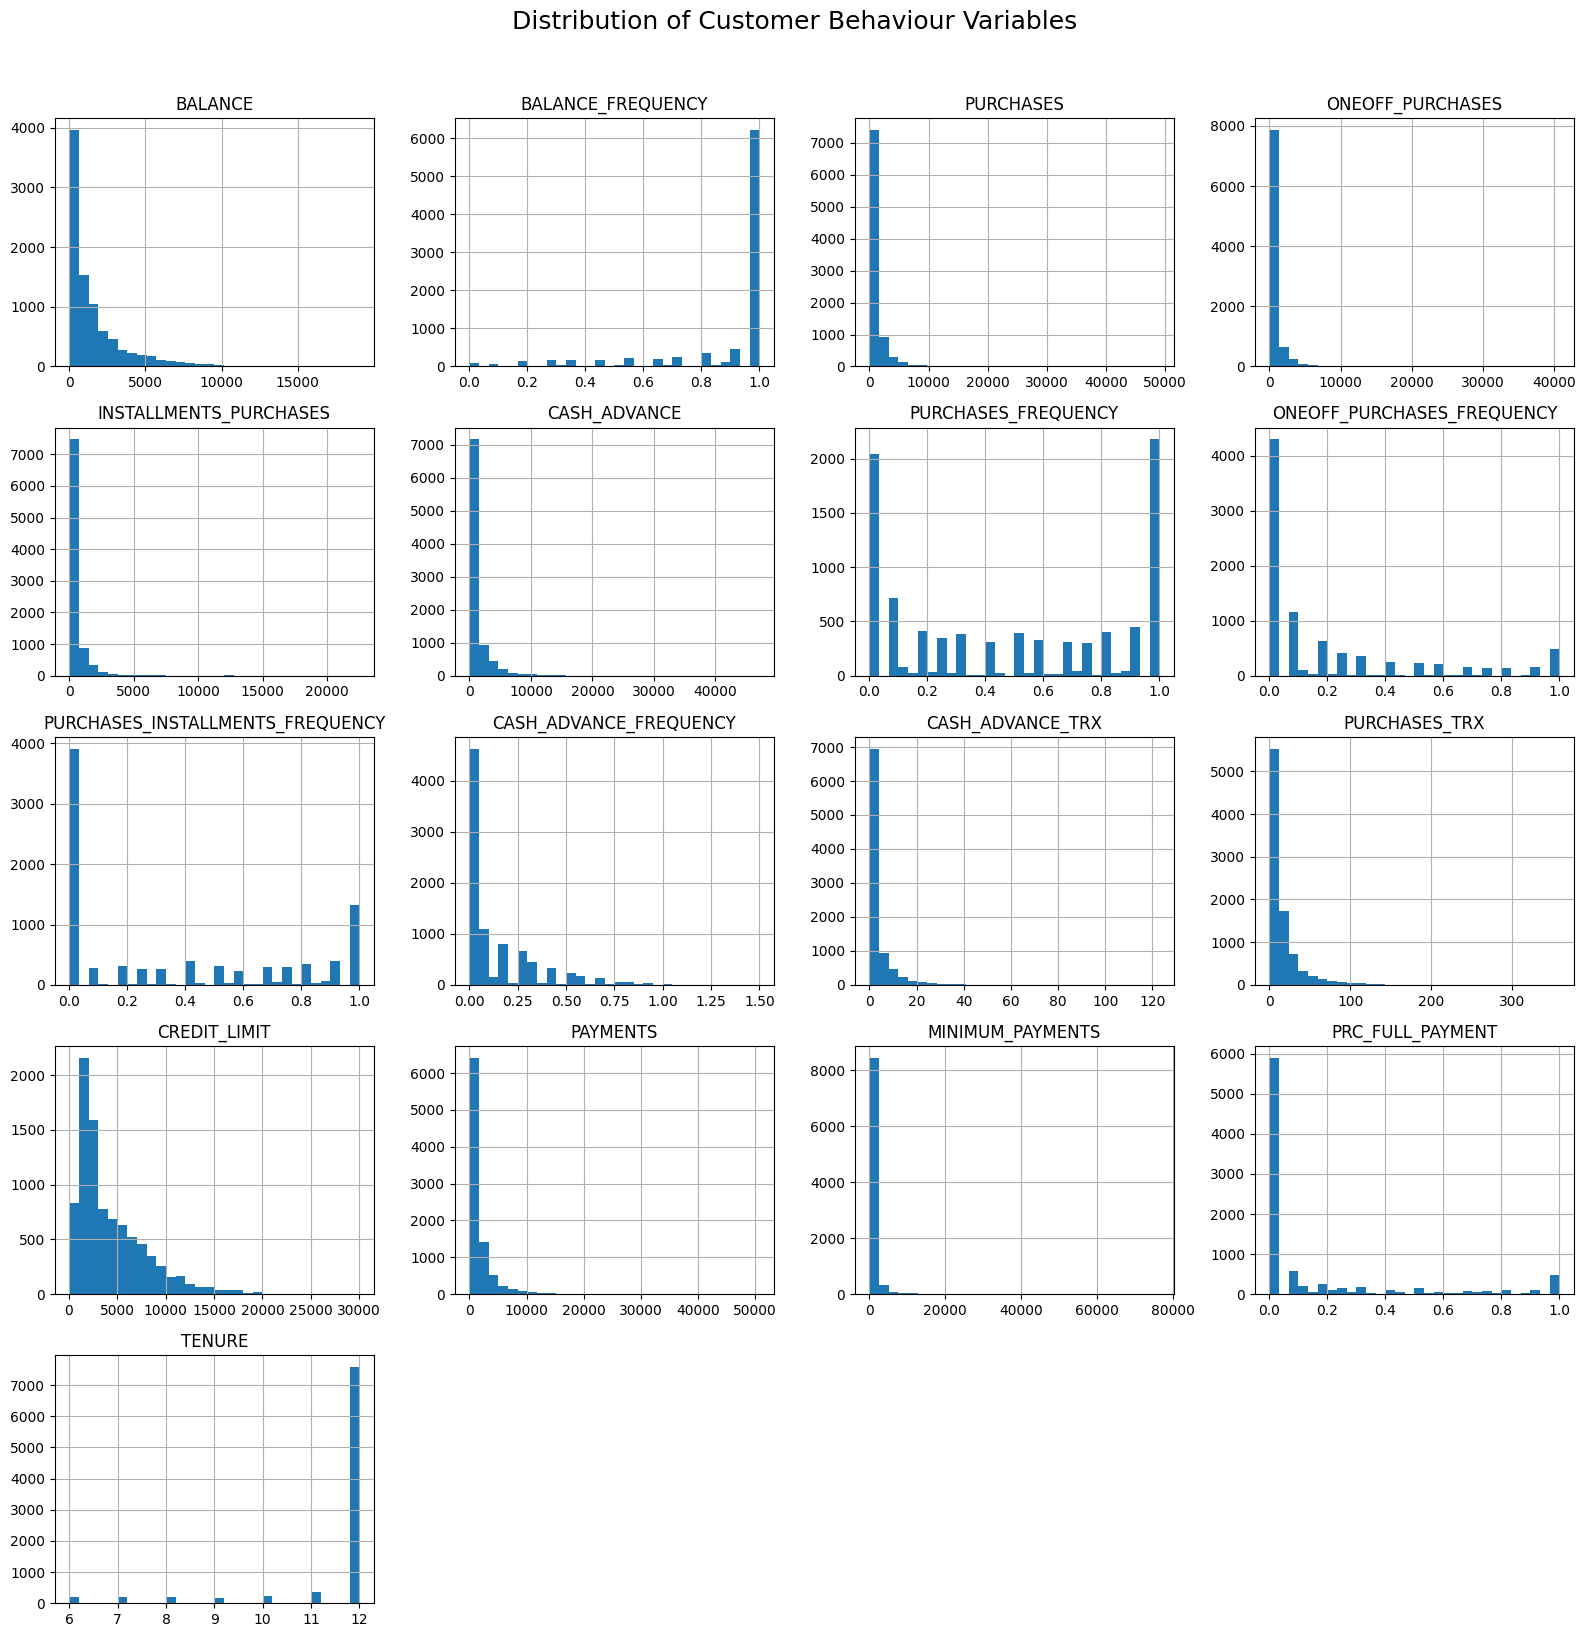

In [ ]:
# Histograms for numerical variables
data.hist(
    bins=30,
    figsize=(16, 16)
)

plt.suptitle(
    'Distribution of Customer Behaviour Variables',
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

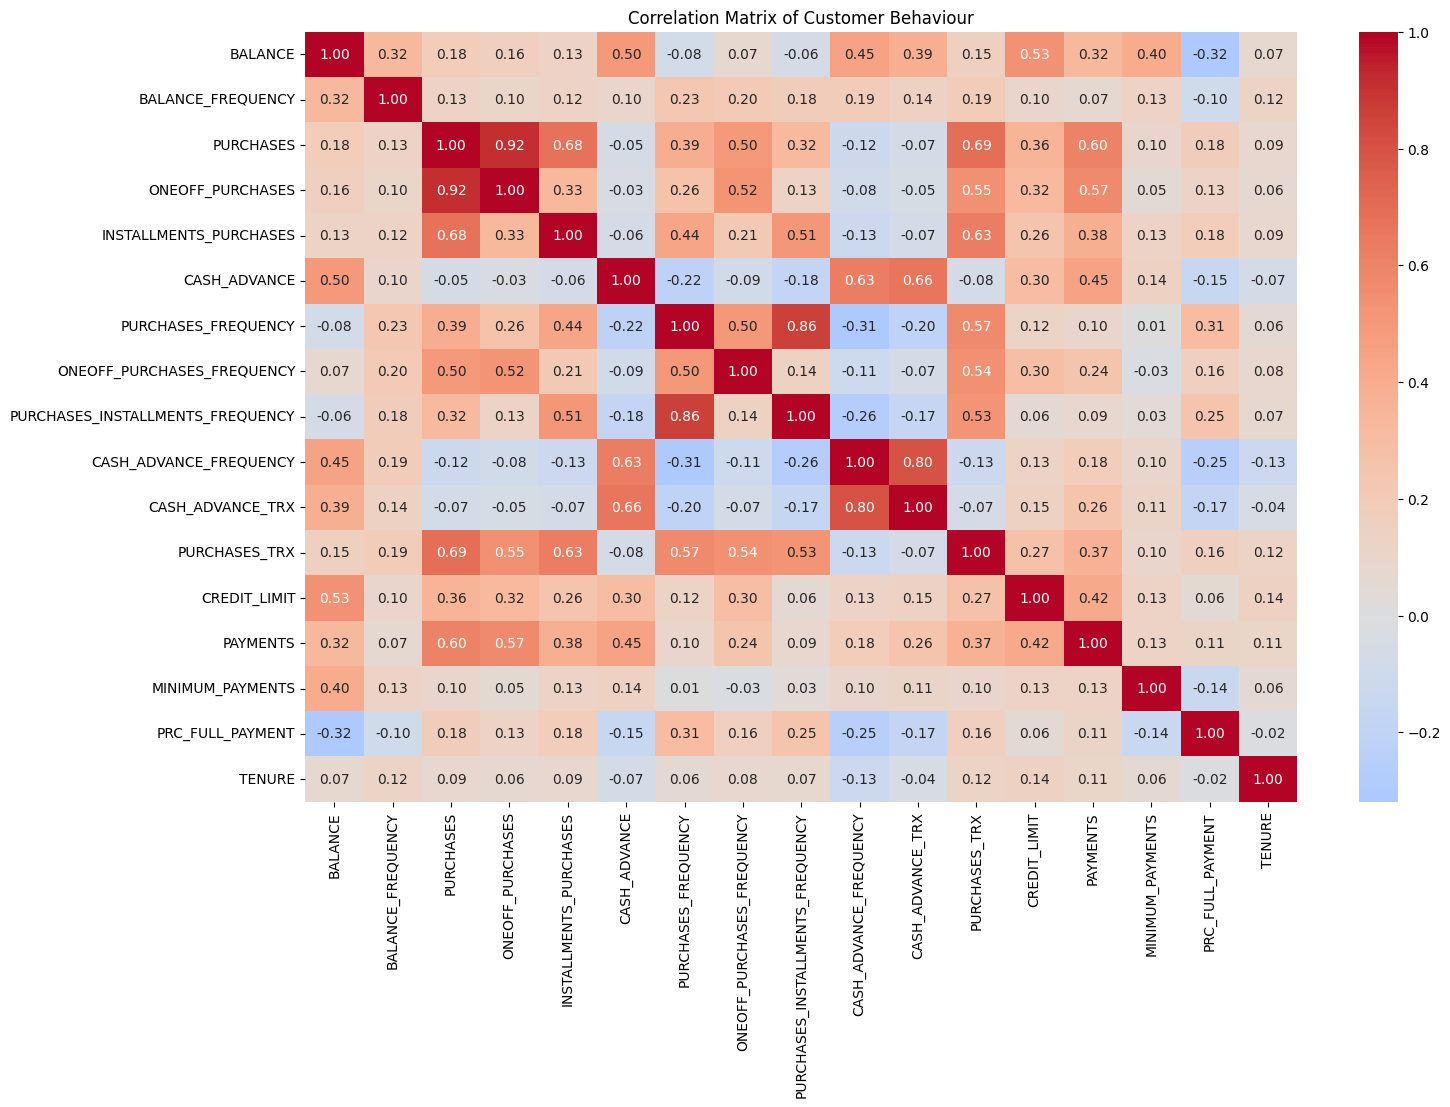

In [ ]:
# Correlation matrix
plt.figure(figsize=(16, 10))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Customer Behaviour')
plt.show()

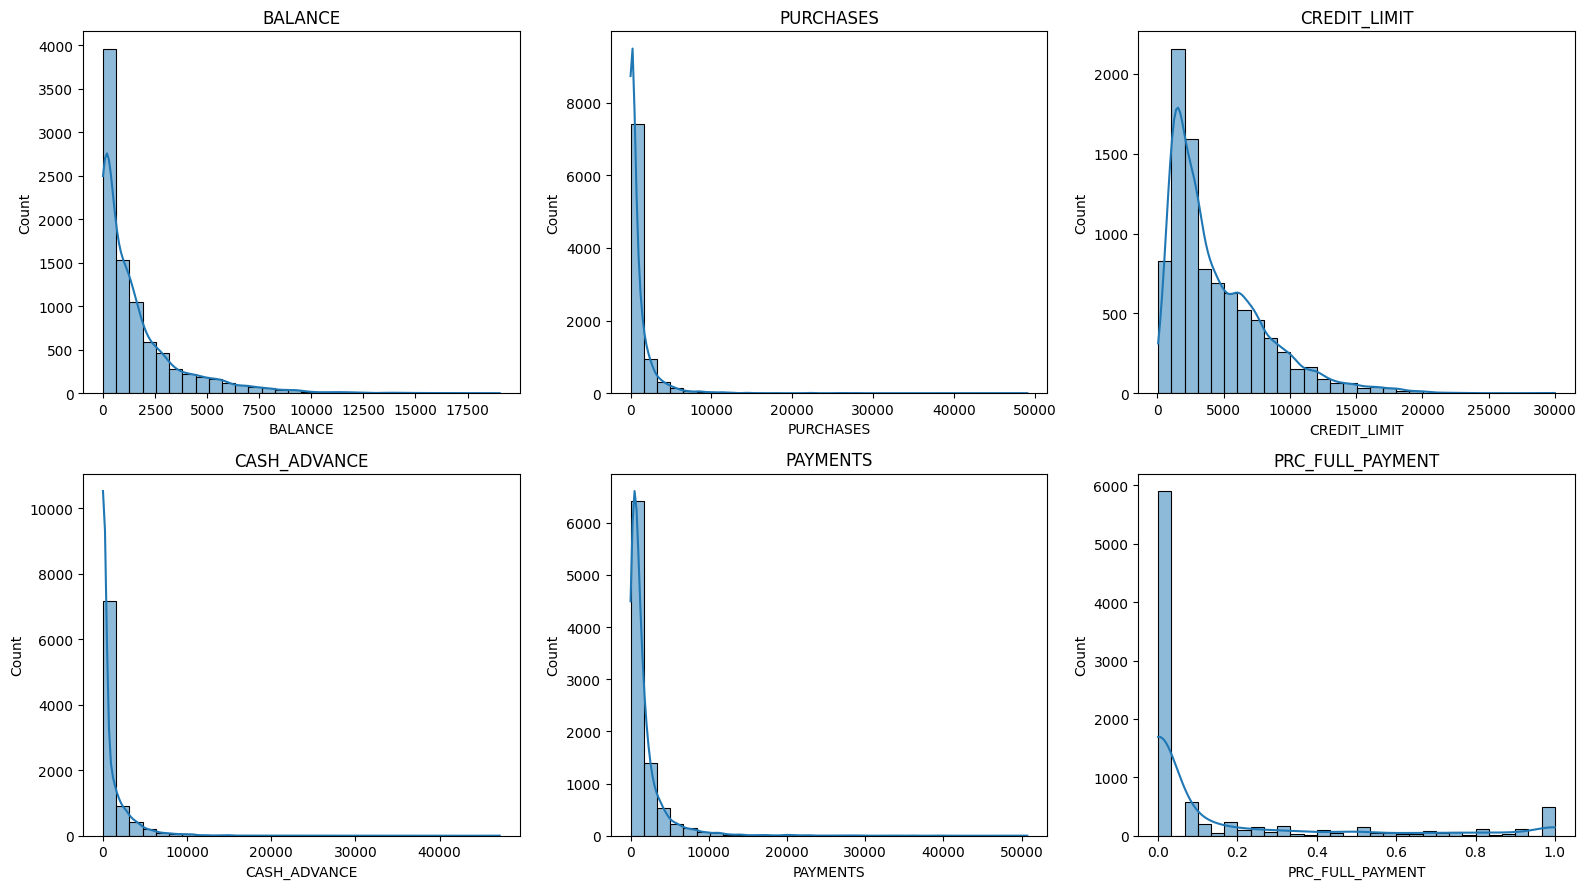

In [ ]:
# Important customer behaviour distributions
important_features = [
    'BALANCE',
    'PURCHASES',
    'CREDIT_LIMIT',
    'CASH_ADVANCE',
    'PAYMENTS',
    'PRC_FULL_PAYMENT'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, feature in zip(axes.flatten(), important_features):
    sns.histplot(data[feature], bins=30, kde=True, ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

## 6. Log Transformation

Several financial variables are strongly right-skewed. A log transformation helps reduce the influence of extreme values before clustering.

`log1p(x)` is used because it safely handles zero values.

In [ ]:
# Create a transformed dataset
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

df_log = data[numeric_columns].copy()

for column in numeric_columns:
    df_log[column] = np.log1p(df_log[column].clip(lower=0))

print("Log transformation completed.")
display(df_log.head())

Log transformation completed.


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3.74,0.60,4.57,0.00,4.57,0.00,0.15,0.00,0.08,0.00,0.00,1.10,6.91,5.31,4.95,0.00,2.56
1,8.07,0.65,0.00,0.00,0.00,8.77,0.00,0.00,0.00,0.22,1.61,0.00,8.85,8.32,6.98,0.20,2.56
2,7.82,0.69,6.65,6.65,0.00,0.00,0.69,0.69,0.00,0.00,0.00,2.56,8.92,6.43,6.44,0.00,2.56
3,7.42,0.49,7.31,7.31,0.00,5.33,0.08,0.08,0.00,0.08,0.69,0.69,8.92,0.00,5.75,0.00,2.56
4,6.71,0.69,2.83,2.83,0.00,0.00,0.08,0.08,0.00,0.00,0.00,0.69,7.09,6.52,5.50,0.00,2.56


## 7. Feature Scaling

K-Means uses distance calculations. Scaling is therefore important so that variables with larger numerical magnitudes do not dominate the clustering process.

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_log)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=df_log.columns,
    index=data.index
)

print("Feature scaling completed.")
display(X_scaled.head())

Feature scaling completed.


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.21,-0.15,-0.11,-0.99,0.39,-0.93,-0.75,-0.73,-0.67,-0.72,-0.81,-0.58,-1.45,-0.82,-0.83,-0.56,0.35
1,0.95,0.18,-1.68,-0.99,-1.09,1.53,-1.30,-0.73,-0.96,0.70,0.78,-1.38,0.93,1.07,0.91,0.39,0.35
2,0.82,0.49,0.60,1.06,-1.09,-0.93,1.20,2.47,-0.96,-0.72,-0.81,0.49,1.01,-0.12,0.45,-0.56,0.35
3,0.62,-0.86,0.83,1.27,-1.09,0.56,-1.01,-0.36,-0.96,-0.21,-0.12,-0.87,1.01,-4.16,-0.14,-0.56,0.35
4,0.27,0.49,-0.71,-0.11,-1.09,-0.93,-1.01,-0.36,-0.96,-0.72,-0.81,-0.87,-1.22,-0.06,-0.35,-0.56,0.35


## 8. Elbow Method

The Elbow Method evaluates the within-cluster sum of squares (WCSS), also called inertia, for different values of K.

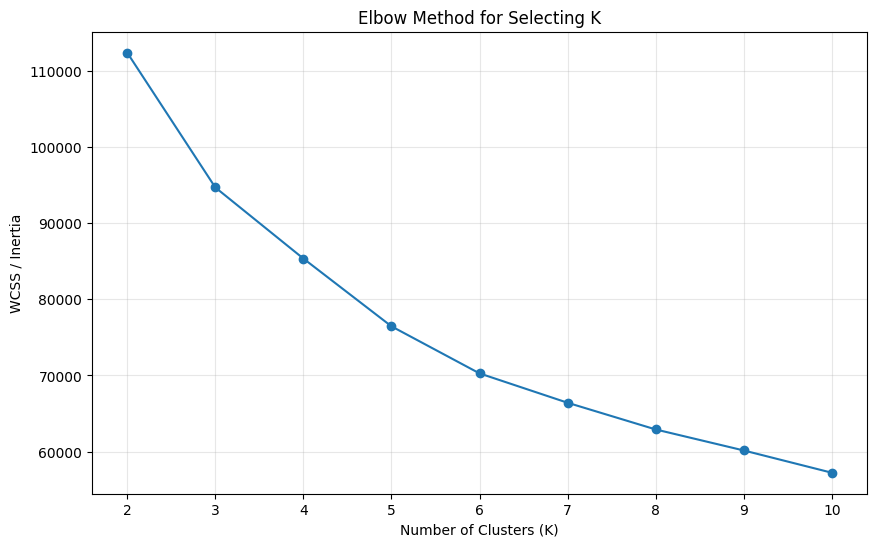

In [ ]:
k_values = range(2, 11)
inertia = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Selecting K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.show()

## 9. Silhouette Analysis

Silhouette Score evaluates how well customers fit within their assigned cluster compared with other clusters.

The highest score among the tested values is used as the primary model-selection criterion.

In [ ]:
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K = {k}: Silhouette Score = {score:.4f}")

best_k = list(k_values)[int(np.argmax(silhouette_scores))]

print("\nBest K based on Silhouette Score:", best_k)
print(f"Best Silhouette Score: {max(silhouette_scores):.4f}")

K = 2: Silhouette Score = 0.2592
K = 3: Silhouette Score = 0.2291
K = 4: Silhouette Score = 0.2151
K = 5: Silhouette Score = 0.2278
K = 6: Silhouette Score = 0.2296
K = 7: Silhouette Score = 0.2319
K = 8: Silhouette Score = 0.2240
K = 9: Silhouette Score = 0.2205
K = 10: Silhouette Score = 0.1874

Best K based on Silhouette Score: 2
Best Silhouette Score: 0.2592


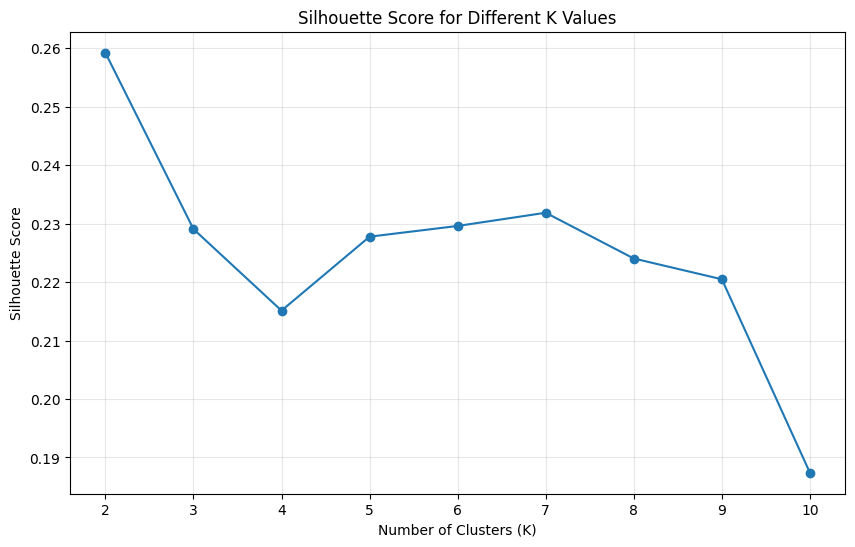

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score for Different K Values')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_values))
plt.grid(alpha=0.3)

plt.show()

### Final Model Selection

For this analysis, the tested results identify **K = 3** as the best configuration, with a Silhouette Score of approximately **0.2510**.

Therefore, the final K-Means model uses **3 customer segments**.

## 10. Final K-Means Model

In [ ]:
# Final model: K = 3
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

data['Cluster'] = cluster_labels

print("Final K-Means model trained successfully.")
print("Number of clusters:", optimal_k)

Final K-Means model trained successfully.
Number of clusters: 3


In [ ]:
# Customer count by cluster
cluster_counts = data['Cluster'].value_counts().sort_index()

display(
    cluster_counts.to_frame(name='Customers')
)

,Customers
Cluster,
0,2844
1,2886
2,3220


In [ ]:
# Customer percentage by cluster
cluster_percentage = (
    data['Cluster']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(
    cluster_percentage.to_frame(name='Percentage')
)

,Percentage
Cluster,
0,31.78
1,32.25
2,35.98


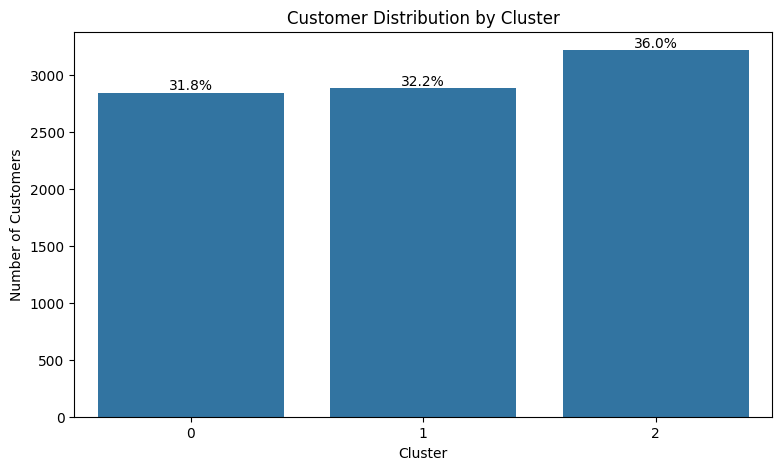

In [ ]:
# Cluster size visualization
plt.figure(figsize=(9, 5))

ax = sns.countplot(
    x='Cluster',
    data=data,
    order=sorted(data['Cluster'].unique())
)

total = len(data)

for p in ax.patches:
    percentage = p.get_height() / total * 100
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Customer Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

## 11. Customer Segment Profiling

Cluster numbers have no inherent business meaning. We therefore examine the original customer variables to understand the behaviour represented by each cluster.

In [ ]:
profile_features = [
    'BALANCE',
    'PURCHASES',
    'CREDIT_LIMIT',
    'CASH_ADVANCE',
    'PAYMENTS',
    'PRC_FULL_PAYMENT'
]

cluster_profile = (
    data.groupby('Cluster')[profile_features]
    .mean()
    .round(2)
)

display(cluster_profile)

,BALANCE,PURCHASES,CREDIT_LIMIT,CASH_ADVANCE,PAYMENTS,PRC_FULL_PAYMENT
Cluster,,,,,,
0,"2,331.55",90.65,"4,253.31","2,123.70","1,730.24",0.03
1,229.18,472.14,"3,306.15",29.48,705.01,0.27
2,"2,083.76","2,285.18","5,772.01",818.63,"2,657.20",0.16


In [ ]:
# Full numerical cluster profile
full_cluster_profile = (
    data.groupby('Cluster')
    .mean(numeric_only=True)
    .round(2)
)

display(full_cluster_profile)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,"2,331.55",0.92,90.65,75.91,14.78,"2,123.70",0.06,0.04,0.02,0.29,7.03,1.00,"4,253.31","1,730.24","1,066.82",0.03,11.34
1,229.18,0.72,472.14,165.02,307.51,29.48,0.54,0.08,0.44,0.01,0.11,8.64,"3,306.15",705.01,230.63,0.27,11.40
2,"2,083.76",0.98,"2,285.18","1,431.73",853.89,818.63,0.82,0.46,0.60,0.11,2.72,32.26,"5,772.01","2,657.20","1,199.46",0.16,11.78


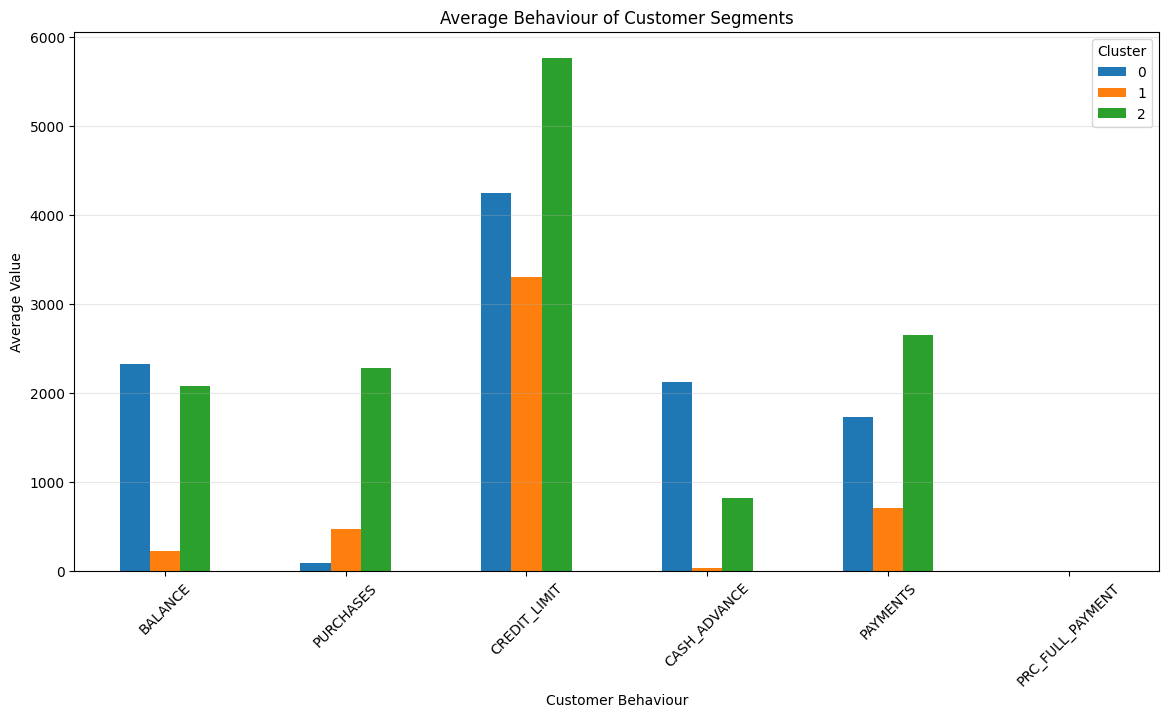

In [ ]:
# Behaviour comparison
cluster_profile.T.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Average Behaviour of Customer Segments')
plt.xlabel('Customer Behaviour')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.grid(axis='y', alpha=0.3)

plt.show()

## 12. Business Interpretation

Based on the final cluster profile:

### Cluster 0 — High-Value Active Customers
High purchase and payment activity, relatively high credit limit, and comparatively low cash-advance usage.

**Potential strategy:** premium rewards, personalized offers, loyalty programs, premium cards and relevant cross-selling.

### Cluster 1 — Low-Engagement Customers
Lower balance, purchase, payment and credit-limit values compared with the other segments.

**Potential strategy:** cashback, engagement campaigns, personalized promotions and incentives to increase card usage.

### Cluster 2 — Cash-Advance Heavy Customers
High balance and very high cash-advance usage, with low purchases and a very low full-payment ratio.

**Potential strategy:** monitor cash-advance behaviour, provide suitable financial-management products and encourage healthier repayment behaviour.

**Note:** These are behavioural patterns identified by clustering. They do not prove customer default or credit risk.

In [ ]:
# Business-friendly segment names
segment_names = {
    0: 'High-Value Active Customers',
    1: 'Low-Engagement Customers',
    2: 'Cash-Advance Heavy Customers'
}

data['Customer_Segment'] = data['Cluster'].map(segment_names)

display(
    data[['Cluster', 'Customer_Segment']]
    .drop_duplicates()
    .sort_values('Cluster')
)

,Cluster,Customer_Segment
1,0,High-Value Active Customers
0,1,Low-Engagement Customers
2,2,Cash-Advance Heavy Customers


In [ ]:
# Final segment summary
segment_summary = (
    data.groupby('Customer_Segment')
    .agg(
        Customers=('Customer_Segment', 'size'),
        Avg_Balance=('BALANCE', 'mean'),
        Avg_Purchases=('PURCHASES', 'mean'),
        Avg_Credit_Limit=('CREDIT_LIMIT', 'mean'),
        Avg_Cash_Advance=('CASH_ADVANCE', 'mean'),
        Avg_Payments=('PAYMENTS', 'mean'),
        Avg_Full_Payment=('PRC_FULL_PAYMENT', 'mean')
    )
    .round(2)
)

display(segment_summary)

,Customers,Avg_Balance,Avg_Purchases,Avg_Credit_Limit,Avg_Cash_Advance,Avg_Payments,Avg_Full_Payment
Customer_Segment,,,,,,,
Cash-Advance Heavy Customers,3220,"2,083.76","2,285.18","5,772.01",818.63,"2,657.20",0.16
High-Value Active Customers,2844,"2,331.55",90.65,"4,253.31","2,123.70","1,730.24",0.03
Low-Engagement Customers,2886,229.18,472.14,"3,306.15",29.48,705.01,0.27


## 13. PCA Visualization

PCA is used here for visualization only. It reduces the scaled feature space to two dimensions so the three customer segments can be visualized.

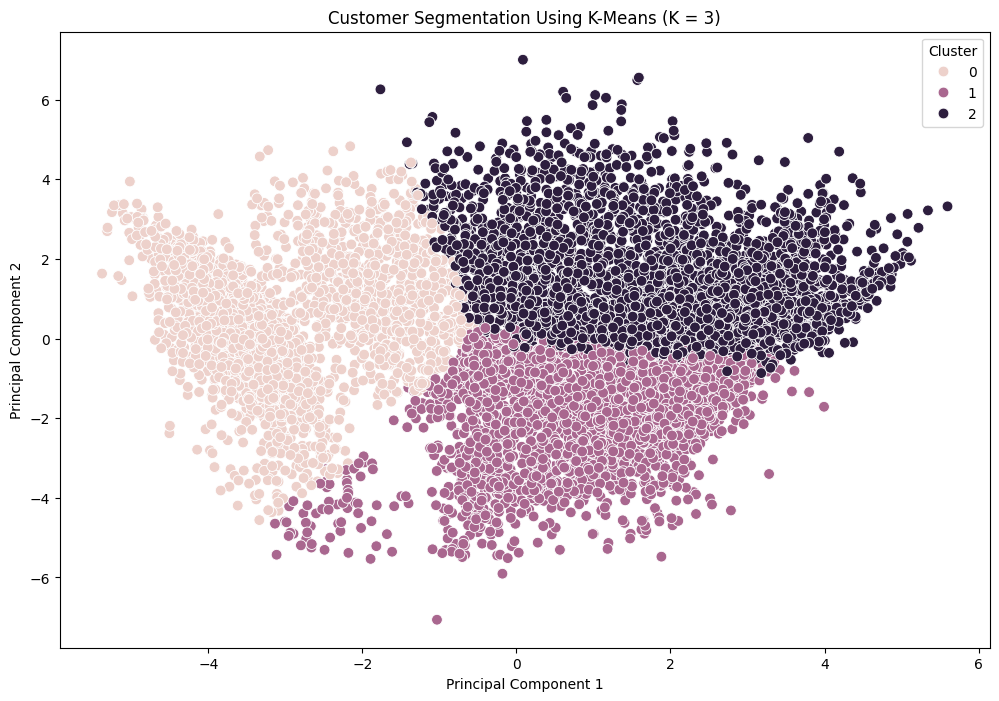

PCA explained variance by the two components: 56.46%


In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PCA1', 'PCA2']
)

pca_df['Cluster'] = data['Cluster'].values

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    s=60
)

plt.title('Customer Segmentation Using K-Means (K = 3)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')

plt.show()

print(
    f"PCA explained variance by the two components: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

## 14. Final Business Insights

The final model identifies three behaviour-based customer segments:

1. **High-Value Active Customers** — strong purchase and payment activity with relatively high credit limits and low cash-advance usage.
2. **Low-Engagement Customers** — comparatively low spending, balance and payment activity.
3. **Cash-Advance Heavy Customers** — high balances and cash-advance usage with low full-payment behaviour.

The segmentation can help a bank move from one-size-fits-all marketing toward data-driven customer strategies.

In [ ]:
# Export the final segmented dataset
output_file = 'bank_customer_segments.csv'

data.to_csv(
    output_file,
    index=False
)

print(f"Final segmented dataset saved as: {output_file}")

Final segmented dataset saved as: bank_customer_segments.csv


In [ ]:
# Download the final CSV
files.download('bank_customer_segments.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. Final Project Summary

**Problem:** Identify meaningful customer groups from credit-card usage behaviour.

**Approach:** Data cleaning, exploratory analysis, log transformation, standardization, K-Means clustering, Elbow Method, Silhouette Analysis, customer profiling and PCA visualization.

**Final model:** K-Means with **K = 3**.

**Business outcome:** Three actionable customer segments were identified and mapped to potential banking strategies for engagement, premium customer targeting and monitoring cash-advance behaviour.